## Day 12: Logistic Regression & Classification Metrics

Model Accuracy: 0.9737


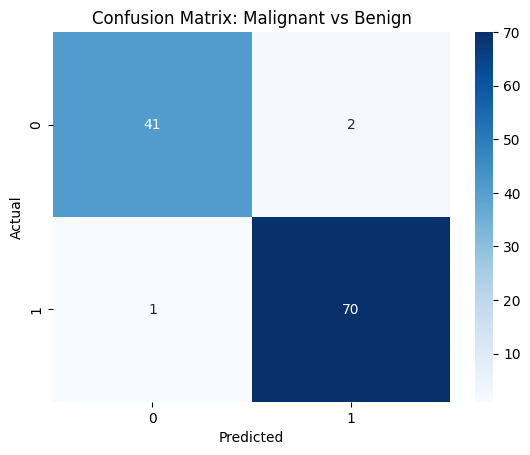

In [1]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix

# 1. Load Data
data = load_breast_cancer()

X_train, X_test, y_train, y_test = train_test_split(
    data.data, data.target, test_size=0.2, random_state=42
)

# 2. Scale Data (VERY IMPORTANT)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 3. Train Model
model = LogisticRegression()
model.fit(X_train_scaled, y_train)

# 4. Predict
y_pred = model.predict(X_test_scaled)

# 5. Accuracy
print(f"Model Accuracy: {accuracy_score(y_test, y_pred):.4f}")


import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix: Malignant vs Benign')
plt.show()

In [2]:
model.predict_proba(X_test_scaled)[:5]

array([[1.13590250e-01, 8.86409750e-01],
       [9.99990991e-01, 9.00936206e-06],
       [9.96920905e-01, 3.07909541e-03],
       [5.10134225e-04, 9.99489866e-01],
       [6.06389713e-05, 9.99939361e-01]])

### Reflection: False Positive vs False Negative

In a medical scenario like cancer detection, a False Negative is more dangerous than a False Positive.

A False Negative means the model predicts that a patient is healthy when they actually have cancer. This can delay diagnosis and treatment, which may lead to serious consequences or even risk the patient’s life.

On the other hand, a False Positive means a healthy person is predicted as having cancer. While this can cause stress and lead to additional medical tests, it is generally safer compared to missing an actual disease.

Therefore, minimizing False Negatives is more important in such critical applications.